In [1]:
import pandas as pd
import sqlite3

connexion = sqlite3.connect(r"C:\Users\HP 1030 G7\Desktop\casa_market.db")

atw = pd.read_sql(
    "SELECT date, value FROM cours WHERE ticker = 'ATW' ORDER BY date",
    connexion)
atw.head()

,date,value
0,2021-07-12 00:00:00,445.00
1,2021-07-13 00:00:00,441.00
2,2021-07-14 00:00:00,440.60
3,2021-07-15 00:00:00,441.05
4,2021-07-16 00:00:00,442.10


In [5]:
atw['rendement'] = atw['value'].pct_change()
atw = atw.dropna()
atw.head()

,date,value,rendement
1,2021-07-13 00:00:00,441.00,-0.008989
2,2021-07-14 00:00:00,440.60,-0.000907
3,2021-07-15 00:00:00,441.05,0.001021
4,2021-07-16 00:00:00,442.10,0.002381
5,2021-07-19 00:00:00,442.60,0.001131


In [6]:
atw['rendement'].describe() #count → le nombre de rendements/mean → la moyenne (proche de 0 ?)/std → l'écart-type = la volatilité = le risque d'ATW/ 50% =  la moitié des jours bouge ou ne bouge pas 

count    1241.000000
mean        0.000415
std         0.011903
min        -0.051661
25%        -0.005381
50%         0.000000
75%         0.005183
max         0.059928
Name: rendement, dtype: float64

In [7]:
import numpy as np
vol_annuelle = atw['rendement'].std() * np.sqrt(252)
print(f"Volatilité annualisée d'ATW : {vol_annuelle:.2%}")

Volatilité annualisée d'ATW : 18.89%


In [8]:
from scipy.stats import shapiro
stat, p_value = shapiro(atw['rendement'])
print(f"Statistique de test : {stat:.4f}")
print(f"p-value : {p_value:.6f}")

Statistique de test : 0.9344
p-value : 0.000000


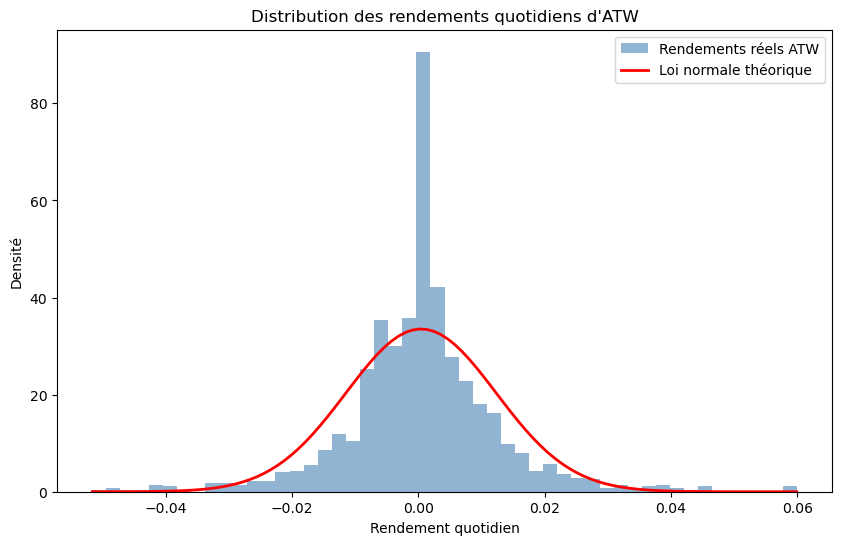

In [9]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm

rendements = atw['rendement']
plt.figure(figsize=(10, 6))
# Histogramme des rendements réels
plt.hist(rendements, bins=50, density=True, alpha=0.6, color='steelblue', label='Rendements réels ATW')
# Courbe normale théorique (même moyenne, même écart-type)
x = np.linspace(rendements.min(), rendements.max(), 100)
plt.plot(x, norm.pdf(x, rendements.mean(), rendements.std()), 'r-', linewidth=2, label='Loi normale théorique')

plt.title("Distribution des rendements quotidiens d'ATW")
plt.xlabel("Rendement quotidien")
plt.ylabel("Densité")
plt.legend()
plt.show()